# Principal Component Analysis

This is the second unsupervised algorithm in the repository, and it builds on the K-Means notebook. There I clustered the seeds dataset using all 7 measurements, but I could only ever plot 2 of them at a time, so I never actually saw the 7-dimensional shape the clustering was working with. PCA is what lets me see it. It takes those 7 features, finds the few directions that hold the most spread, and rebuilds the data along them so I can keep just 2 and still capture almost everything.

PCA doesn't look at the labels, it is unsupervised, it only studies how the features vary among themselves. But it is almost always used as a setup step before a supervised model, so at the end I train a classifier on the original 7 features and again on the compressed version to see whether compressing actually helps.

I use the same seeds data from the K-Means notebook: 210 wheat kernels, 7 measurements each, from 3 varieties (Kama, Rosa, Canadian).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme()
PALETTE = {"Kama": "#5d32ca", "Rosa": "#82b600", "Canadian": "#e07b39"}   # purple, green, orange

# Load the seeds dataset: 210 wheat kernels with 7 physical measurements and a variety label
# Try the remote URL first, fall back to the local copy if unavailable
cols = ["area", "perimeter", "compactness", "kernel_length",
        "kernel_width", "asymmetry", "groove_length", "variety"]
try:
    df = pd.read_csv("https://raw.githubusercontent.com/Narahari917/seeds/master/seeds_dataset.csv",
                     sep=r"\s+", header=None, names=cols)
    variety_names = {1: "Kama", 2: "Rosa", 3: "Canadian"}
    df["variety"] = df["variety"].map(variety_names)
except Exception:
    df = pd.read_csv("../Datasets/seeds.csv")

features = [c for c in df.columns if c != "variety"]

X = df[features].to_numpy(float)
y = df["variety"].to_numpy()
# Standardize: the 7 measurements are on different scales (area ~15 vs asymmetry ~3),
# and PCA judges spread by distance, so one big-range feature would dominate without this.
X_scaled = StandardScaler().fit_transform(X)
print(len(df), "kernels |", len(features), "features | varieties:", dict(pd.Series(y).value_counts()))

210 kernels | 7 features | varieties: {'Kama': np.int64(70), 'Rosa': np.int64(70), 'Canadian': np.int64(70)}


## How It Works

The first step is the standardizing which I do by subtracting each feature's mean and divide by its standard deviation. Call that centered and scaled matrix $A$.

Then PCA looks for the direction in this 7-dimensional space along which the data spreads out the most. That direction is the first principal component, $PC_1$. The next one, $PC_2$, is the direction of most *remaining* spread that is perpendicular to the first, and so on, one component per feature. Each component is a recipe, a weighted mix of all 7 original features, and those weights are called loading scores.

The clean way to find all of them at once is the singular value decomposition of the centered data,

$$A = U \Sigma V^{T},$$

where the rows of $V^{T}$ are the principal components and the singular values in $\Sigma$ say how much spread each one captures. Squaring a singular value and dividing by the total gives the fraction of variance that component explains. To compress, I project the data onto the first few components and drop the rest.

In [2]:
class PCAScratch:
    """PCA by the SVD of the centered data, following the lecture's A = U S Vt."""
    def __init__(self, n_components=None):
        self.n_components = n_components

    def fit(self, X):
        # Save the column means so transform can center new data the same way
        self.mean_ = X.mean(axis=0)

        # Center the data by subtracting the mean of each feature
        A = X - self.mean_

        # SVD decomposes A into U * S * Vt
        # Rows of Vt are the principal component directions
        # Singular values in S tell how much spread each direction captures
        U, S, Vt = np.linalg.svd(A, full_matrices=False)

        # Variance explained by each PC: square the singular value, divide by total
        self.explained_variance_ratio_ = S**2 / (S**2).sum()

        # Keep all components if n_components wasn't set, otherwise keep the top k
        k = self.n_components or Vt.shape[0]
        self.components_ = Vt[:k]
        return self

    def transform(self, X):
        # Project centered data onto the kept principal components
        return (X - self.mean_) @ self.components_.T

    def fit_transform(self, X):
        return self.fit(X).transform(X)

Before trusting it, I check the from-scratch version against scikit-learn. The explained-variance ratios match exactly, which confirms the SVD route and scikit-learn's `PCA` are computing the same thing.

In [3]:
from sklearn.decomposition import PCA

# Fit both implementations on the same standardized data
mine = PCAScratch().fit(X_scaled)
sk = PCA().fit(X_scaled)
# Compare variance explained per component (as percentages)
print("from scratch:", np.round(mine.explained_variance_ratio_ * 100, 1), "%")
print("scikit-learn:", np.round(sk.explained_variance_ratio_ * 100, 1), "%")
print("identical:", np.allclose(mine.explained_variance_ratio_, sk.explained_variance_ratio_))

from scratch: [71.9 17.1  9.7  1.   0.3  0.1  0. ] %
scikit-learn: [71.9 17.1  9.7  1.   0.3  0.1  0. ] %
identical: True


## Choosing How Many Components

The scree plot shows how much variance each component explains, with the running total on top. It is how you decide where to cut: keep enough components to cover most of the variance, then drop the rest.

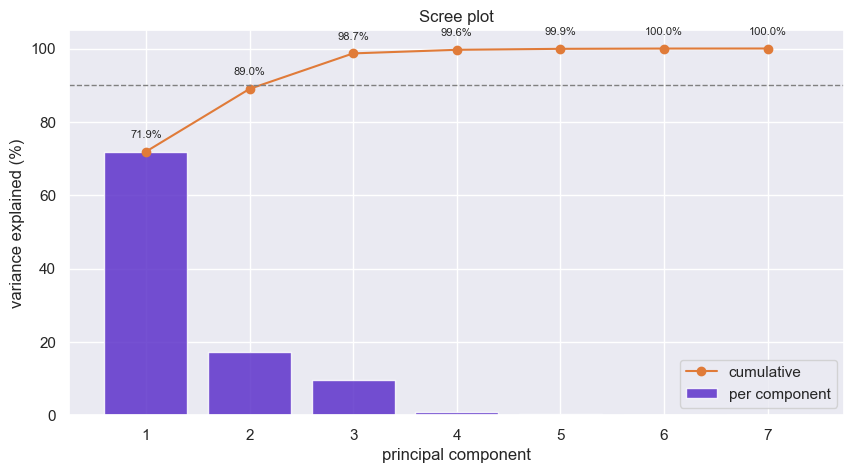

PC1 + PC2 hold 89.0% of the variance | 3 components hold 98.7%


In [4]:
evr = mine.explained_variance_ratio_
cum = np.cumsum(evr)                     # running total of variance explained
n90 = int(np.argmax(cum >= 0.90) + 1)    # fewest PCs needed to pass 90%

fig, ax = plt.subplots(figsize=(10, 5))
# Bars: variance explained by each individual component
ax.bar(range(1, len(evr) + 1), evr * 100, color="#5d32ca", alpha=0.85, label="per component")
# Line: cumulative variance as components are added
ax.plot(range(1, len(evr) + 1), cum * 100, "o-", color="#e07b39", label="cumulative")
# Label each cumulative dot with its exact percentage
for i, c in enumerate(cum):
    ax.annotate(f"{c*100:.1f}%", (i + 1, c * 100), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=8)
ax.axhline(90, color="gray", ls="--", lw=1)   # 90% threshold reference line
ax.set_xlabel("principal component"); ax.set_ylabel("variance explained (%)")
ax.set_title("Scree plot"); ax.legend()
plt.show()
print(f"PC1 + PC2 hold {cum[1]*100:.1f}% of the variance | {n90} components hold {cum[n90-1]*100:.1f}%")

This is a good case for PCA because the first two components alone hold about 89% of the variance, and three reach about 99% of it. That happens because the seven measurements are highly redundant, area, perimeter, length, and width are all really describing how big the kernel is, so they rise and fall together. PCA folds that shared size signal into a single component, which is exactly the situation where PCA proves it worth. I can keep two components and lose almost nothing.

## What the Components Are Made Of

Each component is a linear combination of all 7 features. The loading scores below are the weights, and the features with the largest size weights are what each component mostly captures.

In [5]:
# Build a table of loading scores: each row is a feature, each column is a PC
loadings = pd.DataFrame(mine.components_[:2].T, index=features, columns=["PC1", "PC2"])
print(loadings.round(2))
# Show the top 3 features by absolute weight for each component
print("\nPC1 leans most on:", loadings["PC1"].abs().sort_values(ascending=False).head(3).index.tolist())
print("PC2 leans most on:", loadings["PC2"].abs().sort_values(ascending=False).head(3).index.tolist())

                PC1   PC2
area          -0.44 -0.03
perimeter     -0.44 -0.08
compactness   -0.28  0.53
kernel_length -0.42 -0.21
kernel_width  -0.43  0.12
asymmetry      0.12 -0.72
groove_length -0.39 -0.38

PC1 leans most on: ['area', 'perimeter', 'kernel_width']
PC2 leans most on: ['asymmetry', 'compactness', 'groove_length']


$PC_1$ loads on the size measurements all in the same direction, so it really is an "overall kernel size" axis, the redundant signal PCA collapsed. $PC_2$ leans on shape features like compactness and asymmetry, capturing what is left once size is accounted for.

## Biplot

The biplot overlays two layers of information onto a single set of axes which is the projected data scores and the original feature loadings. Each of the 210 data points appears as a dot, colored by its variety (Kama, Rosa, or Canadian), plotted at its PC1 and PC2 coordinates, the same scatter as the 2D projection below, showing how the data points spread and cluster in the reduced space.

On top of that scatter, each of the 7 original features is drawn as an arrow starting from the origin and the direction of an arrow shows the combination of PC1 and PC2 that feature contributes to: an arrow pointing far to the left along PC1 means that feature loads heavily on the size axis, while one pointing up along PC2 means it loads on the shape axis. The length of the arrow reflects how strongly that feature is represented in the first two components, a long arrow means the feature is well captured by this 2D view, while a short one means most of its information lives in later components that are not shown.

The angles between arrows encode correlations so arrows pointing in roughly the same direction (like area, perimeter, kernel_width, and kernel_length) indicate features that rise and fall together, they share the redundant size signal that PC1 captures. Arrows at roughly 90 degrees (like area and asymmetry) are nearly uncorrelated in this projection. Arrows pointing in opposite directions would indicate features that trade off against each other: when one is high, the other tends to be low.

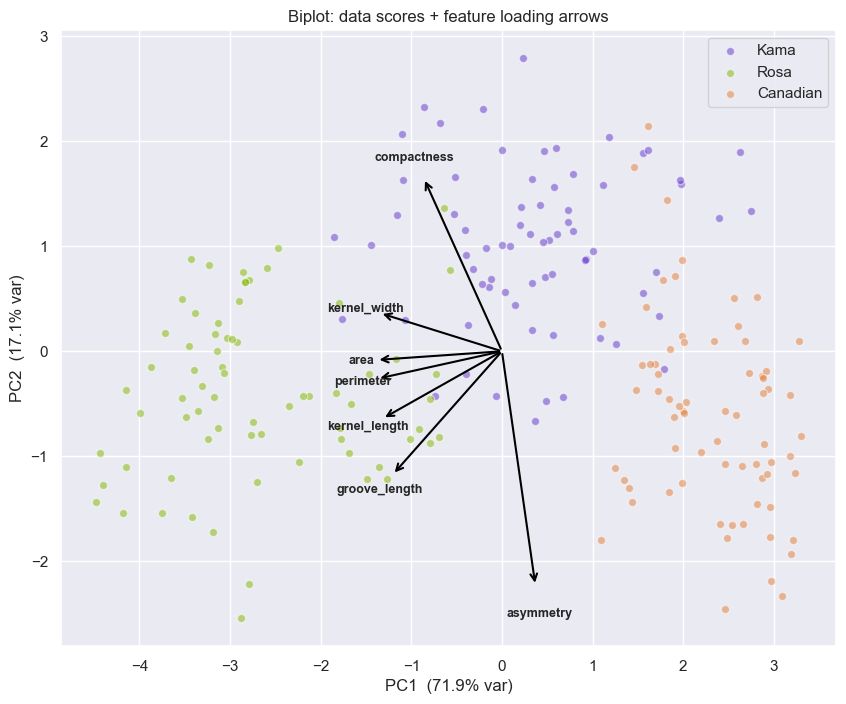

In [6]:
# Project data onto first 2 PCs
P = PCAScratch(n_components=2).fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))

# Scatter: each kernel colored by variety
for name, color in PALETTE.items():
    m = y == name
    ax.scatter(P[m, 0], P[m, 1], color=color, alpha=0.5, edgecolors="white", s=35, label=name)

# Arrows: scale loadings so they're visible against the scatter
# Multiplier chosen so arrows span roughly half the plot range
scale = max(P[:, 0].max() - P[:, 0].min(), P[:, 1].max() - P[:, 1].min()) * 0.4
for i, feat in enumerate(features):
    dx = mine.components_[0, i] * scale
    dy = mine.components_[1, i] * scale
    ax.annotate("", xy=(dx, dy), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="black", lw=1.5))
    ax.text(dx * 1.12, dy * 1.12, feat, fontsize=9, ha="center", va="center", fontweight="bold")

ax.set_xlabel(f"PC1  ({evr[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2  ({evr[1]*100:.1f}% var)")
ax.set_title("Biplot: data scores + feature loading arrows")
ax.legend()
plt.show()

## Seeing the Data in 2D

Now is the value I wanted from the K-Means notebook: projecting all 7 features down to the first two components so I can finally plot the whole dataset at once, colored by variety.

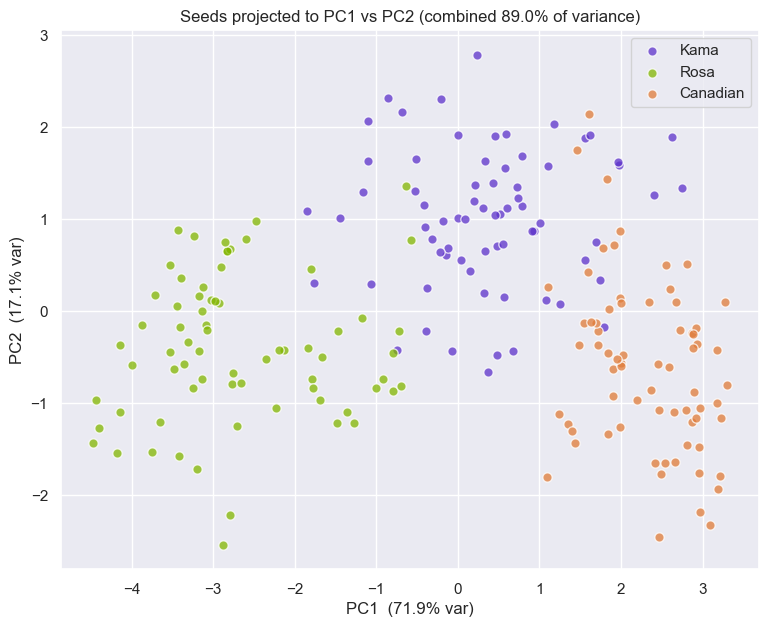

In [7]:
# Change these two to plot different components (0 = PC1, 1 = PC2, 2 = PC3, etc.)
pc_x = 0
pc_y = 1

# Project all 7 features down to enough components
P = PCAScratch(n_components=max(pc_x, pc_y) + 1).fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
# Plot each variety separately so they get their own color and legend entry
for name, color in PALETTE.items():
    m = y == name
    plt.scatter(P[m, pc_x], P[m, pc_y], color=color, alpha=0.75, edgecolors="white", s=45, label=name)
plt.xlabel(f"PC{pc_x+1}  ({evr[pc_x]*100:.1f}% var)")
plt.ylabel(f"PC{pc_y+1}  ({evr[pc_y]*100:.1f}% var)")
plt.title(f"Seeds projected to PC{pc_x+1} vs PC{pc_y+1} (combined {(evr[pc_x]+evr[pc_y])*100:.1f}% of variance)")
plt.legend()
plt.show()

The three varieties fall into clear bands, mostly separated along $PC_1$. This is the structure the K-Means clustering was latching onto when it recovered the varieties at an adjusted Rand index of 0.77, except now I can actually see it instead of trusting a number, because two components are enough to hold 89% of the data.

## Does PCA Actually Help a Classifier?

This is the real test where I train two classifiers on the original 7 features, then on the PCA-compressed versions, and compare test accuracy. KNN is the same model from the KNN notebook; logistic regression is the one from earlier. If PCA is keeping the important information, the compressed accuracy should hold up.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 70% train, 30% test, stratified so each variety is equally represented in both
Xtr, Xte, ytr, yte = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

def accuracy_on(n_components, model):
    # If no PCA, use the raw features directly
    if n_components is None:
        Atr, Ate = Xtr, Xte
    else:
        # Fit PCA on training data only, then transform both splits
        p = PCAScratch(n_components).fit(Xtr)
        Atr, Ate = p.transform(Xtr), p.transform(Xte)
    # Train the classifier and return test accuracy
    model.fit(Atr, ytr)
    return accuracy_score(yte, model.predict(Ate))

# Compare each model on raw features, 2 PCs, and n90 PCs
rows = []
for name, make in [("KNN (k=15)", lambda: KNeighborsClassifier(15)),
                   ("Logistic Regression", lambda: LogisticRegression(max_iter=1000))]:
    rows.append([name, accuracy_on(None, make()), accuracy_on(2, make()), accuracy_on(n90, make())])

table = pd.DataFrame(rows, columns=["model", "raw (7 features)", "PCA (2 comps)", f"PCA ({n90} comps, {cum[n90-1]*100:.0f}% var)"])
print(table.to_string(index=False))

              model  raw (7 features)  PCA (2 comps)  PCA (3 comps, 99% var)
         KNN (k=15)          0.873016       0.888889                0.888889
Logistic Regression          0.904762       0.888889                0.873016


Compressing 7 features down to 2 did not cost any accuracy, it nudged KNN slightly up. Dropping to two components mostly removed noise rather than signal, so the classifier had a slightly cleaner space to work in. That is the textbook PCA win as its fewer features, same or better accuracy.

## Conclusion

PCA rotated the 7 seed measurements into 7 independent components ranked by variance, and the from-scratch SVD matched scikit-learn exactly. This is the clean case: the first two components hold about 89% of the variance, so I compressed 7 features down to 2 and the classifier accuracy held and even ticked up. It worked because the measurements are highly correlated, all tied to kernel size, so there was real redundancy for PCA to fold together. It is also the picture the K-Means notebook was missing, the 7-dimensional structure finally drawn in 2D, where the three varieties separate cleanly along the size axis.

The reason this went so well is because PCA only helps when there is redundancy to remove. When features are highly correlated like these, a couple of components capture nearly everything and compressing is almost free. When every feature carries its own independent signal, the variance spreads evenly, no small set of components dominates, and cutting down throws away information instead. Seeds is the friendly end of that spectrum.

The standing cost is interpretability. $PC_1$ captures overall kernel size, but it is a blend of all 7 measurements, not a single quantity an agronomist could point to, so I traded away the ability to name which original feature drove a result which can hurt in some real world applications.